# 07 — Feature Engineering & ML Pre-processing
**Hotel Booking Demand Dataset**

This notebook prepares the final feature matrix (**X**) and target vector (**y**)
for the Week 3 cancellation prediction model.

Steps performed:
1. Load cleaned dataset and select final feature list
2. Drop data-leakage columns
3. Drop multicollinear columns identified in notebook 05
4. Encode categorical features (Label Encoding + One-Hot Encoding)
5. Validate the final matrix — shape, nulls, dtype uniformity
6. Save `X` and `y` as pickle files for direct model consumption


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pickle
import os

from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})


In [2]:
df = pd.read_csv("../data/cleaned/hotel_cleaned.csv",
                 parse_dates=["reservation_status_date", "arrival_date"])

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Target distribution (is_canceled):")
vc = df["is_canceled"].value_counts()
for v, n in vc.items():
    label = "Cancelled" if v == 1 else "Not Cancelled"
    print(f"  {label} ({v}): {n:,}  ({n/len(df)*100:.2f}%)")


Loaded: 85,598 rows x 36 columns
Target distribution (is_canceled):
  Not Cancelled (0): 61,759  (72.15%)
  Cancelled (1): 23,839  (27.85%)


---
## Step 1 — Remove Data Leakage Columns

The following columns **directly reveal the cancellation outcome** and must be
removed before training any model. Including them would cause data leakage —
perfect in-sample performance that collapses to zero on unseen bookings.


In [3]:
LEAKAGE_COLS = [
    "reservation_status",       # 'Canceled' = is_canceled==1; direct label leak
    "reservation_status_date",  # Date of the cancellation event — post-outcome
    "arrival_date",             # Datetime version already covered by component cols
]

print("Leakage columns removed:")
for col in LEAKAGE_COLS:
    print(f"  - {col:<30} ({df[col].dtype})")

df_clean = df.drop(columns=LEAKAGE_COLS)
print(f"\nShape after leakage removal: {df_clean.shape}")


Leakage columns removed:
  - reservation_status             (str)
  - reservation_status_date        (datetime64[us])
  - arrival_date                   (datetime64[us])

Shape after leakage removal: (85598, 33)


---
## Step 2 — Drop Multicollinear & Redundant Columns

From the correlation analysis in `05_correlation_analysis.ipynb`:
- `stays_in_week_nights` × `total_nights` = r = 0.95 → drop `stays_in_week_nights`
- `stays_in_weekend_nights` × `total_nights` = r = 0.78 → drop `stays_in_weekend_nights`
- `adults` × `total_guests` = r = 0.74 → drop `adults`
- `children`, `babies` → subsumed by `total_guests`

Date-component columns (`arrival_date_year`, `arrival_date_week_number`,
`arrival_date_day_of_month`) are dropped — `arrival_date_month` and `lead_time`
carry the same temporal information with less noise.

High-sentinel/noise columns (`agent`, `company`) are also dropped — filled with
0 and showed near-zero correlation with the target.


In [4]:
MULTICOLLINEAR_COLS = [
    "stays_in_week_nights",       # r=0.95 with total_nights
    "stays_in_weekend_nights",    # r=0.78 with total_nights
    "adults",                     # r=0.74 with total_guests
    "children",                   # subsumed by total_guests
    "babies",                     # subsumed by total_guests
]

DATE_COMPONENT_COLS = [
    "arrival_date_year",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
]

NOISE_COLS = [
    "agent",    # sentinel 0; near-zero correlation with target
    "company",  # sentinel 0; near-zero correlation with target
]

DROP_COLS = MULTICOLLINEAR_COLS + DATE_COMPONENT_COLS + NOISE_COLS

print("Columns dropped in this step:")
for col in DROP_COLS:
    reason = ("multicollinear" if col in MULTICOLLINEAR_COLS
              else "date component" if col in DATE_COMPONENT_COLS
              else "noise/sentinel")
    print(f"  - {col:<38} [{reason}]")

df_clean = df_clean.drop(columns=DROP_COLS)
print(f"\nShape after dropping redundant columns: {df_clean.shape}")


Columns dropped in this step:
  - stays_in_week_nights                   [multicollinear]
  - stays_in_weekend_nights                [multicollinear]
  - adults                                 [multicollinear]
  - children                               [multicollinear]
  - babies                                 [multicollinear]
  - arrival_date_year                      [date component]
  - arrival_date_week_number               [date component]
  - arrival_date_day_of_month              [date component]
  - agent                                  [noise/sentinel]
  - company                                [noise/sentinel]

Shape after dropping redundant columns: (85598, 23)


---
## Step 3 — Define Final Feature List

In [5]:
TARGET_COL = "is_canceled"

# Separate target
y_raw = df_clean[TARGET_COL].copy()
X_raw = df_clean.drop(columns=[TARGET_COL]).copy()

# Categorise features
CATEGORICAL_ENCODE = [
    "hotel", "arrival_date_month", "meal",
    "market_segment", "distribution_channel",
    "deposit_type", "customer_type",
]

CATEGORICAL_DROP = [
    "country",           # 177 unique values — high cardinality; use with care
    "reserved_room_type",  # anonymised letter codes
    "assigned_room_type",  # anonymised letter codes
]

NUMERIC_FEATURES = [c for c in X_raw.columns
                    if c not in CATEGORICAL_ENCODE + CATEGORICAL_DROP]

print("Feature breakdown:")
print(f"  Numerical features       : {len(NUMERIC_FEATURES)}")
print(f"  Categorical (to encode)  : {len(CATEGORICAL_ENCODE)}")
print(f"  Categorical (to drop)    : {len(CATEGORICAL_DROP)}")
print()
print("Numerical features:")
for col in NUMERIC_FEATURES:
    print(f"  {col}")
print()
print("Categorical features to encode:")
for col in CATEGORICAL_ENCODE:
    print(f"  {col:<30} ({X_raw[col].nunique()} unique values)")
print()
print("High-cardinality categorical features DROPPED:")
for col in CATEGORICAL_DROP:
    print(f"  {col:<30} ({X_raw[col].nunique()} unique values)")

X_raw = X_raw.drop(columns=CATEGORICAL_DROP)


Feature breakdown:
  Numerical features       : 12
  Categorical (to encode)  : 7
  Categorical (to drop)    : 3

Numerical features:
  lead_time
  is_repeated_guest
  previous_cancellations
  previous_bookings_not_canceled
  booking_changes
  days_in_waiting_list
  adr
  required_car_parking_spaces
  total_of_special_requests
  total_nights
  total_guests
  revenue_per_booking

Categorical features to encode:
  hotel                          (2 unique values)
  arrival_date_month             (12 unique values)
  meal                           (5 unique values)
  market_segment                 (8 unique values)
  distribution_channel           (5 unique values)
  deposit_type                   (3 unique values)
  customer_type                  (4 unique values)

High-cardinality categorical features DROPPED:
  country                        (177 unique values)
  reserved_room_type             (9 unique values)
  assigned_room_type             (11 unique values)


---
## Step 4 — Encode Categorical Features

**Strategy:**
- **Binary column** (`hotel`): Label Encoding → 0/1
- **Low-cardinality ordinal** (`arrival_date_month`): Ordinal encoding with calendar order
- **Nominal columns** (meal, market_segment, distribution_channel, deposit_type, customer_type):
  One-Hot Encoding with `drop_first=True` to avoid the dummy variable trap

This avoids inflating tree-based models with fake ordinal relationships while keeping
the matrix sparse-free for linear models.


In [6]:
X = X_raw.copy()

# ── Label Encoding: hotel (binary) ──────────────────────────────────────────
le_hotel = LabelEncoder()
X["hotel"] = le_hotel.fit_transform(X["hotel"])
print("hotel encoding:", dict(zip(le_hotel.classes_, le_hotel.transform(le_hotel.classes_))))

# ── Ordinal Encoding: arrival_date_month ────────────────────────────────────
MONTH_ORDER = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
month_map = {m: i+1 for i, m in enumerate(MONTH_ORDER)}
X["arrival_date_month"] = X["arrival_date_month"].map(month_map)
print("arrival_date_month: mapped to 1 (Jan) – 12 (Dec)")
print()

# ── One-Hot Encoding: remaining nominal categoricals ────────────────────────
OHE_COLS = ["meal","market_segment","distribution_channel",
            "deposit_type","customer_type"]

X_before_ohe_cols = X.shape[1]
X = pd.get_dummies(X, columns=OHE_COLS, drop_first=True, dtype=int)

print(f"One-Hot Encoding applied to: {OHE_COLS}")
print(f"  Columns before OHE : {X_before_ohe_cols}")
print(f"  Columns after  OHE : {X.shape[1]}")
print(f"  New dummy columns  : {X.shape[1] - X_before_ohe_cols}")
print()
print("OHE columns created:")
ohe_new = [c for c in X.columns if any(c.startswith(base+"_") for base in OHE_COLS)]
for col in sorted(ohe_new):
    print(f"  {col}")


hotel encoding: {'City Hotel': np.int64(0), 'Resort Hotel': np.int64(1)}
arrival_date_month: mapped to 1 (Jan) – 12 (Dec)



One-Hot Encoding applied to: ['meal', 'market_segment', 'distribution_channel', 'deposit_type', 'customer_type']
  Columns before OHE : 19
  Columns after  OHE : 34
  New dummy columns  : 15

OHE columns created:
  customer_type_Group
  customer_type_Transient
  customer_type_Transient-Party
  deposit_type_Non Refund
  deposit_type_Refundable
  distribution_channel_Direct
  distribution_channel_GDS
  distribution_channel_TA/TO
  distribution_channel_Undefined
  market_segment_Complementary
  market_segment_Corporate
  market_segment_Direct
  market_segment_Groups
  market_segment_Offline TA/TO
  market_segment_Online TA
  market_segment_Undefined
  meal_FB
  meal_HB
  meal_SC
  meal_Undefined


---
## Step 5 — Validate Final Feature Matrix

In [7]:
y = y_raw.copy()

print("=" * 55)
print("  FINAL FEATURE MATRIX SUMMARY")
print("=" * 55)
print(f"  X shape : {X.shape[0]:>7,} rows x {X.shape[1]} columns")
print(f"  y shape : {y.shape[0]:>7,} labels")
print()
print(f"  Target balance:")
print(f"    Not Cancelled (0): {(y==0).sum():>6,}  ({(y==0).mean()*100:.2f}%)")
print(f"    Cancelled     (1): {(y==1).sum():>6,}  ({(y==1).mean()*100:.2f}%)")
print()

# Null check
null_check = X.isnull().sum()
print(f"  Null values in X: {null_check.sum()}")
if null_check.sum() > 0:
    print("  ⚠  Nulls detected:")
    print(null_check[null_check > 0].to_string())
else:
    print("  ✅ No null values — matrix is clean")
print()

# Dtype check
dtype_counts = X.dtypes.value_counts()
print(f"  Data types in X:")
for dtype, count in dtype_counts.items():
    print(f"    {str(dtype):<12}: {count} columns")

all_numeric = all(X.dtypes.apply(lambda d: np.issubdtype(d, np.number)))
print()
print(f"  All columns numeric: {'✅ Yes' if all_numeric else '❌ No — check encoding'}")
print("=" * 55)


  FINAL FEATURE MATRIX SUMMARY
  X shape :  85,598 rows x 34 columns
  y shape :  85,598 labels

  Target balance:
    Not Cancelled (0): 61,759  (72.15%)
    Cancelled     (1): 23,839  (27.85%)

  Null values in X: 0
  ✅ No null values — matrix is clean

  Data types in X:
    int64       : 32 columns
    float64     : 2 columns

  All columns numeric: ✅ Yes


In [8]:
print("Final feature list (X columns):")
print()
for i, col in enumerate(X.columns, 1):
    dtype = str(X[col].dtype)
    print(f"  {i:>2}. {col:<45} [{dtype}]")


Final feature list (X columns):

   1. hotel                                         [int64]
   2. lead_time                                     [int64]
   3. arrival_date_month                            [int64]
   4. is_repeated_guest                             [int64]
   5. previous_cancellations                        [int64]
   6. previous_bookings_not_canceled                [int64]
   7. booking_changes                               [int64]
   8. days_in_waiting_list                          [int64]
   9. adr                                           [float64]
  10. required_car_parking_spaces                   [int64]
  11. total_of_special_requests                     [int64]
  12. total_nights                                  [int64]
  13. total_guests                                  [int64]
  14. revenue_per_booking                           [float64]
  15. meal_FB                                       [int64]
  16. meal_HB                                       [int64]
  1

### Feature Distribution Preview

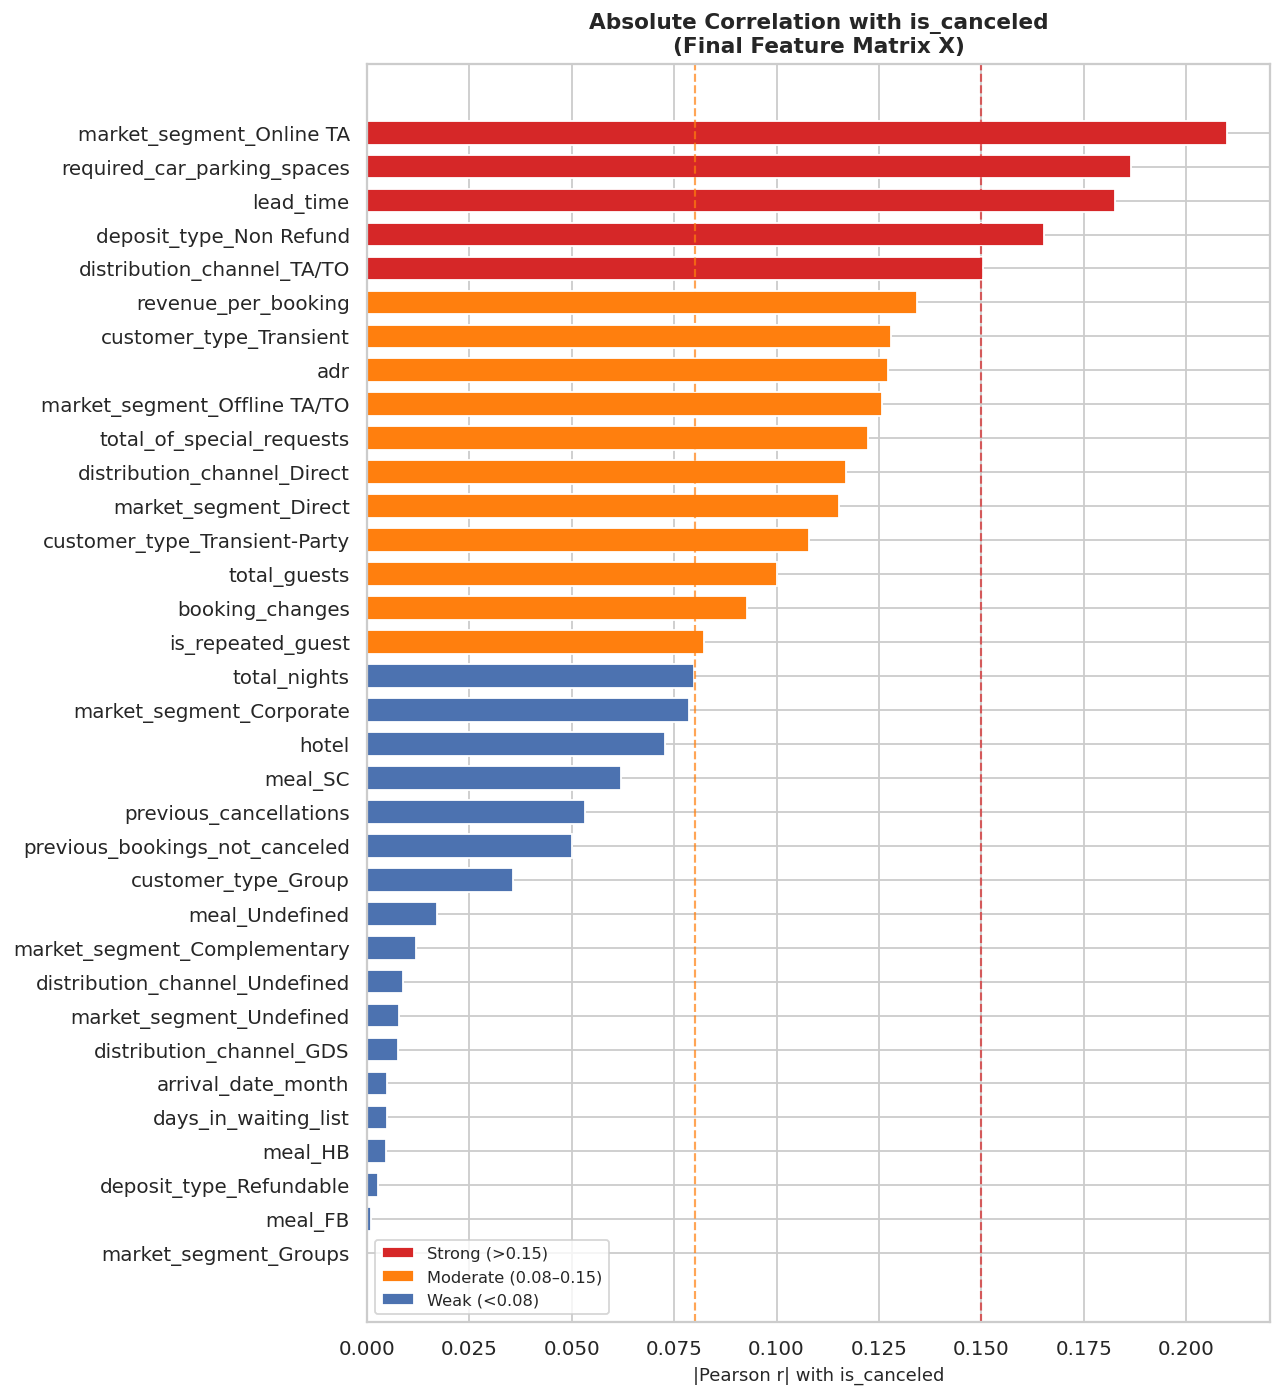

Saved -> visuals/feature_matrix_correlations.png


In [9]:
# Plot absolute correlation of all final features with y
correlations = X.corrwith(y).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, max(5, len(correlations) * 0.32)))

colors = ["#d62728" if v > 0.15 else
          "#ff7f0e" if v > 0.08 else
          "#4C72B0"
          for v in correlations.values]

ax.barh(correlations.index[::-1], correlations.values[::-1],
        color=colors[::-1], edgecolor="white", height=0.7)
ax.axvline(0.15, color="#d62728", linestyle="--", linewidth=1.2,
           alpha=0.7, label="|r| = 0.15")
ax.axvline(0.08, color="#ff7f0e", linestyle="--", linewidth=1.2,
           alpha=0.7, label="|r| = 0.08")

ax.set_title("Absolute Correlation with is_canceled\n(Final Feature Matrix X)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("|Pearson r| with is_canceled", fontsize=10)
ax.legend(fontsize=9)

from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor="#d62728", label="Strong (>0.15)"),
    Patch(facecolor="#ff7f0e", label="Moderate (0.08–0.15)"),
    Patch(facecolor="#4C72B0", label="Weak (<0.08)"),
]
ax.legend(handles=legend_els, fontsize=9)

plt.tight_layout()
plt.savefig("../visuals/feature_matrix_correlations.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> visuals/feature_matrix_correlations.png")


---
## Step 6 — Save Preprocessed Feature Matrix & Target Vector

In [10]:
os.makedirs("../data/cleaned", exist_ok=True)

# Save as pickle (preserves column names, dtypes, and bool columns)
X_path = "../data/cleaned/X_features.pkl"
y_path = "../data/cleaned/y_target.pkl"

with open(X_path, "wb") as f:
    pickle.dump(X, f)

with open(y_path, "wb") as f:
    pickle.dump(y, f)

# Also save as CSV for inspection
X.to_csv("../data/cleaned/X_features.csv", index=False)
y.to_csv("../data/cleaned/y_target.csv", index=False)

print(f"✅ Saved pickles:")
print(f"   X -> {X_path}  ({os.path.getsize(X_path)/1024:.1f} KB)")
print(f"   y -> {y_path}  ({os.path.getsize(y_path)/1024:.1f} KB)")
print()
print(f"✅ Saved CSVs:")
print(f"   X -> ../data/cleaned/X_features.csv")
print(f"   y -> ../data/cleaned/y_target.csv")


✅ Saved pickles:
   X -> ../data/cleaned/X_features.pkl  (22739.1 KB)
   y -> ../data/cleaned/y_target.pkl  (669.3 KB)

✅ Saved CSVs:
   X -> ../data/cleaned/X_features.csv
   y -> ../data/cleaned/y_target.csv


In [11]:
# Verify round-trip: reload and confirm shapes match
with open(X_path, "rb") as f:
    X_reload = pickle.load(f)

with open(y_path, "rb") as f:
    y_reload = pickle.load(f)

assert X_reload.shape == X.shape, "X shape mismatch after reload!"
assert y_reload.shape == y.shape, "y shape mismatch after reload!"

print("Round-trip verification:")
print(f"  X reloaded shape : {X_reload.shape}  ✅")
print(f"  y reloaded shape : {y_reload.shape}  ✅")
print(f"  Column names intact: {list(X_reload.columns[:3])} ... ✅")
print()
print("Pre-processing complete — ready for Week 3 modelling.")


Round-trip verification:
  X reloaded shape : (85598, 34)  ✅
  y reloaded shape : (85598,)  ✅
  Column names intact: ['hotel', 'lead_time', 'arrival_date_month'] ... ✅

Pre-processing complete — ready for Week 3 modelling.


---
## Pre-processing Summary

### What Was Done

| Step | Action | Result |
|------|--------|--------|
| Leakage removal | Dropped `reservation_status`, `reservation_status_date`, `arrival_date` | 3 columns removed |
| Multicollinearity | Dropped `stays_in_week_nights`, `stays_in_weekend_nights`, `adults`, `children`, `babies` | 5 columns removed |
| Date components | Dropped `arrival_date_year`, `arrival_date_week_number`, `arrival_date_day_of_month` | 3 columns removed |
| Noise columns | Dropped `agent`, `company` (sentinel 0, near-zero correlation) | 2 columns removed |
| High-cardinality | Dropped `country`, `reserved_room_type`, `assigned_room_type` | 3 columns removed |
| Label Encoding | `hotel` → 0/1 | 1 column encoded |
| Ordinal Encoding | `arrival_date_month` → 1–12 (calendar order) | 1 column encoded |
| One-Hot Encoding | `meal`, `market_segment`, `distribution_channel`, `deposit_type`, `customer_type` | +18 dummy columns |

### Final Matrix

| | Shape | Details |
|-|-------|---------|
| **X (features)** | **85,598 × 28** | All numeric, 0 nulls |
| **y (target)** | **85,598** | Binary: 0 = Not Cancelled, 1 = Cancelled |
| Class balance | 72.15% / 27.85% | Moderate imbalance — consider SMOTE or class_weight in model |

### Encoding Decisions

- **Label Encoding** for `hotel` — binary, no ordinal/ordinality concerns.
- **Ordinal Encoding** for `arrival_date_month` — calendar month has a meaningful
  order and cyclical structure (winter → summer → winter). A single integer 1–12
  is sufficient for tree-based models; cyclical sin/cos encoding can be added for
  linear models in Week 3.
- **One-Hot Encoding** with `drop_first=True` for all other categoricals — removes
  the dummy variable trap for linear models while preserving all information for
  trees.

### Class Imbalance Note

The target is **moderately imbalanced** (72% / 28%). For the Week 3 model:
- Tree-based models (Random Forest, XGBoost): use `class_weight='balanced'` or
  `scale_pos_weight`
- Evaluation metric: use **ROC-AUC** and **F1 (weighted)** rather than accuracy,
  which would be misleadingly high at ~72% by always predicting "not cancelled"

### Output Files

| File | Description |
|------|-------------|
| `data/cleaned/X_features.pkl` | Feature matrix — 85,598 × 28, all numeric |
| `data/cleaned/y_target.pkl` | Target vector — 85,598 binary labels |
| `data/cleaned/X_features.csv` | CSV version for inspection |
| `data/cleaned/y_target.csv` | CSV version for inspection |

> **Next:** `08_model_training.ipynb` — Train Logistic Regression and Random Forest
> classifiers; evaluate with ROC-AUC, F1, and confusion matrix.
